In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x=np.array([[1,2,3],[4,5,6],[7,8,9]])
print(x)
y=np.array([[1],[0],[1]])
print(y)


[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1]
 [0]
 [1]]


In [3]:
m=len(y)
x=np.hstack([np.ones((m,1)),x])
print(x)
theta=np.zeros((x.shape[1],1))
print(theta)

[[1. 1. 2. 3.]
 [1. 4. 5. 6.]
 [1. 7. 8. 9.]]
[[0.]
 [0.]
 [0.]
 [0.]]


In [4]:
def predict(x,theta):
    return np.dot(x,theta)

In [5]:
def cost_function(x,y,theta):
    m=len(y)
    h=predict(x,theta)
    cost=(1/(2*m))*np.sum((h-y)**2)
    return cost

In [6]:
def gradient(x,y,theta):
    m=len(y)
    h=predict(x,theta)
    grad=(1/m)*np.dot(x.T,(h-y))
    return grad

In [7]:
def gradient_descent(x,y,theta,alpha,num_iters):
    m=len(y)
    cost_history=[]
    for i in range(num_iters):
        h=predict(x,theta)
        theta=theta-(alpha/m)*np.dot(x.T,(h-y))
        cost=cost_function(x,y,theta)
        cost_history.append(cost)
    return theta,cost_history

Optimized theta: [[ 2.21478982e-01]
 [-2.21358370e-01]
 [ 1.20611344e-04]
 [ 2.21599593e-01]]


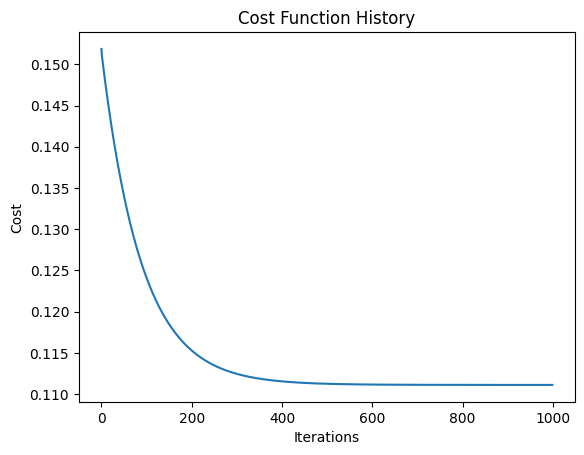

In [8]:
theta,cost_history=gradient_descent(x,y,theta,0.01,1000)
print("Optimized theta:",theta)
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function History")
plt.show()



In [9]:
y_pred = predict(x, theta)
# convert probabilities (array) to binary predictions element-wise
y_pred = (y_pred >= 0.5).astype(int)
print("Predicted values:", y_pred)

Predicted values: [[1]
 [1]
 [1]]


⚠️ Missing features padded with zeros → new_point = [3 3 0]

🔹 Equation: ŷ = 0.221 + -0.221·x1 + 0.000·x2 + 0.222·x3
   Values: x = [3 3 0]
   Prediction = -0.4422 → Class 0


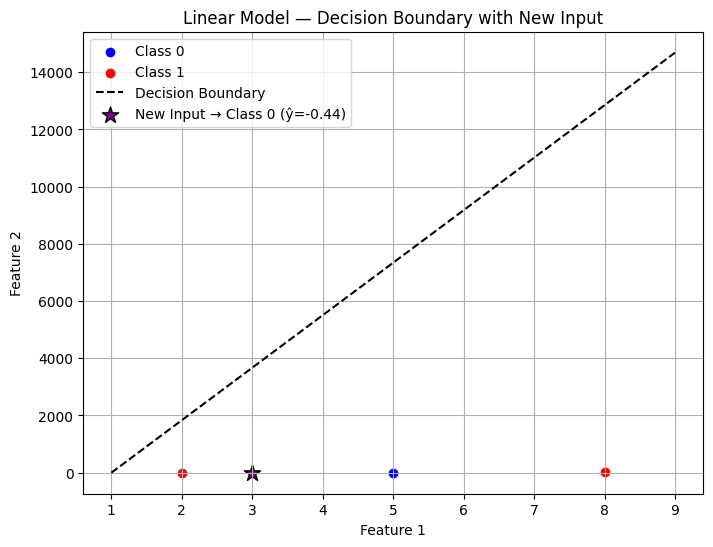

In [25]:
# ==============================================
# ✅ FINAL — Linear Model Classification (Auto-Dimension + Equation)
# ==============================================
import numpy as np
import matplotlib.pyplot as plt

def predict(X, theta):
    """Linear prediction: ŷ = X·θ"""
    return np.dot(X, theta)

def plot_decision_boundary(theta, X, y, new_point=None):
    """
    Plot decision boundary for a linear model and test a new input.
    Automatically adapts to bias + number of features.
    """
    plt.figure(figsize=(8,6))

    theta = theta.ravel()
    y = y.flatten()

    # Step 1: Handle bias
    if X.shape[1] == len(theta) - 1:
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        f1, f2 = 0, 1
    else:
        X_b = X.copy()
        f1, f2 = 1, 2

    # Step 2: Scatter data points
    plt.scatter(X_b[y==0, f1+1], X_b[y==0, f2+1], color='blue', label='Class 0')
    plt.scatter(X_b[y==1, f1+1], X_b[y==1, f2+1], color='red', label='Class 1')

    # Step 3: Decision boundary (only if at least 2 features exist)
    if len(theta) >= 3:
        x1_vals = np.linspace(X_b[:, f1+1].min()-1, X_b[:, f1+1].max()+1, 100)
        x2_vals = -(theta[0] + theta[1]*x1_vals) / theta[2]
        plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary')

    # Step 4: New input test
    if new_point is not None:
        new_point = np.array(new_point)

        # Auto-adjust if fewer features are given
        expected_features = len(theta) - 1
        if len(new_point) < expected_features:
            # pad missing features with mean value 0
            new_point = np.pad(new_point, (0, expected_features - len(new_point)))
            print(f"⚠️ Missing features padded with zeros → new_point = {new_point}")

        x_new = np.concatenate(([1], new_point))
        prediction = predict(x_new, theta)
        predicted_class = int(prediction >= 0.5)

        # Display equation dynamically
        eq_terms = " + ".join([f"{theta[i+1]:.3f}·x{i+1}" for i in range(len(theta)-1)])
        print(f"\n🔹 Equation: ŷ = {theta[0]:.3f} + {eq_terms}")
        print(f"   Values: x = {new_point}")
        print(f"   Prediction = {prediction:.4f} → Class {predicted_class}")

        plt.scatter(new_point[0], new_point[1],
                    color='green' if predicted_class==1 else 'purple',
                    s=150, marker='*', edgecolors='black',
                    label=f'New Input → Class {predicted_class} (ŷ={prediction:.2f})')

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Linear Model — Decision Boundary with New Input")
    plt.legend()
    plt.grid(True)
    plt.show()


# ==============================================
# Example Usage — New Input Test
# ==============================================
# Provide fewer or exact features; function will pad automatically
new_point = [3, 3]  # Missing one → will auto-pad with zero
plot_decision_boundary(theta, x, y, new_point)


⚠️ Missing features padded with zeros → new_point = [3 3 0]

🔹 Equation: ŷ = 0.221 + -0.221·x1 + 0.000·x2 + 0.222·x3
   Values: x = [3 3 0]
   Prediction = -0.4422 → Class 0


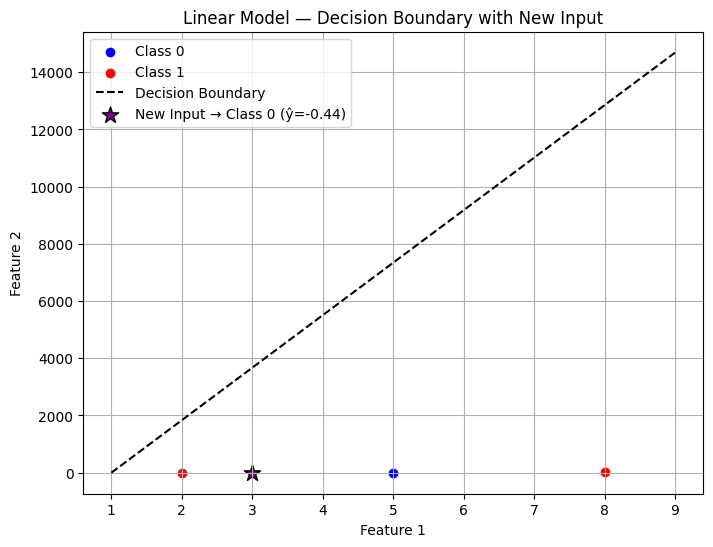

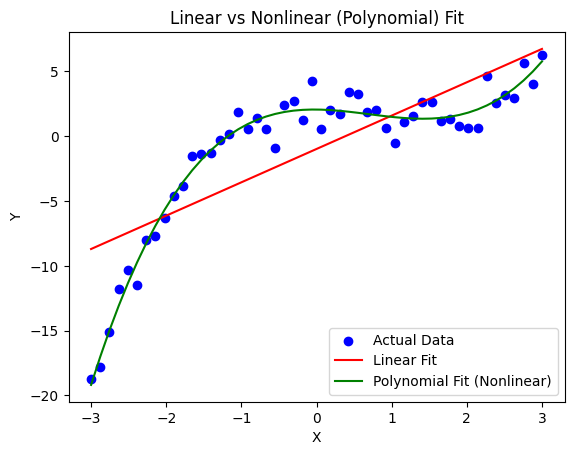

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Create nonlinear data
np.random.seed(0)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = 0.5*X**3 - X**2 + 2 + np.random.randn(50,1)

# Linear Regression
lin_reg = LinearRegression().fit(X, y)
y_lin_pred = lin_reg.predict(X)

# Polynomial Regression (degree 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression().fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# Plot
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_lin_pred, color='red', label='Linear Fit')
plt.plot(X, y_poly_pred, color='green', label='Polynomial Fit (Nonlinear)')
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Nonlinear (Polynomial) Fit")
plt.show()
